Shape: (303, 15)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  303 non-null    int64  
 1   age         303 non-null    int64  
 2   sex         303 non-null    object 
 3   cp          303 non-null    int64  
 4   trestbps    299 non-null    float64
 5   chol        302 non-null    float64
 6   fbs         303 non-null    int64  
 7   restecg     303 non-null    int64  
 8   thalach     298 non-null    float64
 9   exang       303 non-null    int64  
 10  oldpeak     303 non-null    float64
 11  slope       303 non-null    int64  
 12  ca          303 non-null    int64  
 13  thal        303 non-null    int64  
 14  target      303 non-null    object 
dtypes: float64(4), int64(9), object(2)
memory usage: 35.6+ KB
None

Describe (all cols):


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,303.0,NaN,NaN,NaN,151.0,87.612784,0.0,75.5,151.0,226.5,302.0
age,303.0,NaN,NaN,NaN,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303,2,male,207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cp,303.0,NaN,NaN,NaN,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,299.0,NaN,NaN,NaN,131.712375,17.629032,94.0,120.0,130.0,140.0,200.0
chol,302.0,NaN,NaN,NaN,246.317881,51.908285,126.0,211.0,240.5,274.75,564.0
fbs,303.0,NaN,NaN,NaN,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,NaN,NaN,NaN,0.528053,0.52586,0.0,0.0,1.0,1.0,2.0
thalach,298.0,NaN,NaN,NaN,149.865772,22.563687,71.0,134.5,152.5,166.0,202.0
exang,303.0,NaN,NaN,NaN,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0



Missing values per column:


,missing_count
thalach,5
trestbps,4
chol,1
Unnamed: 0,0
age,0
sex,0
cp,0
fbs,0
restecg,0
exang,0


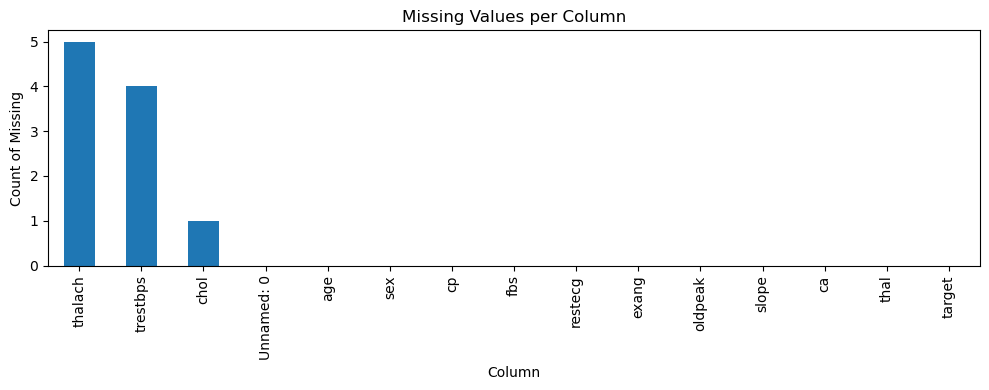

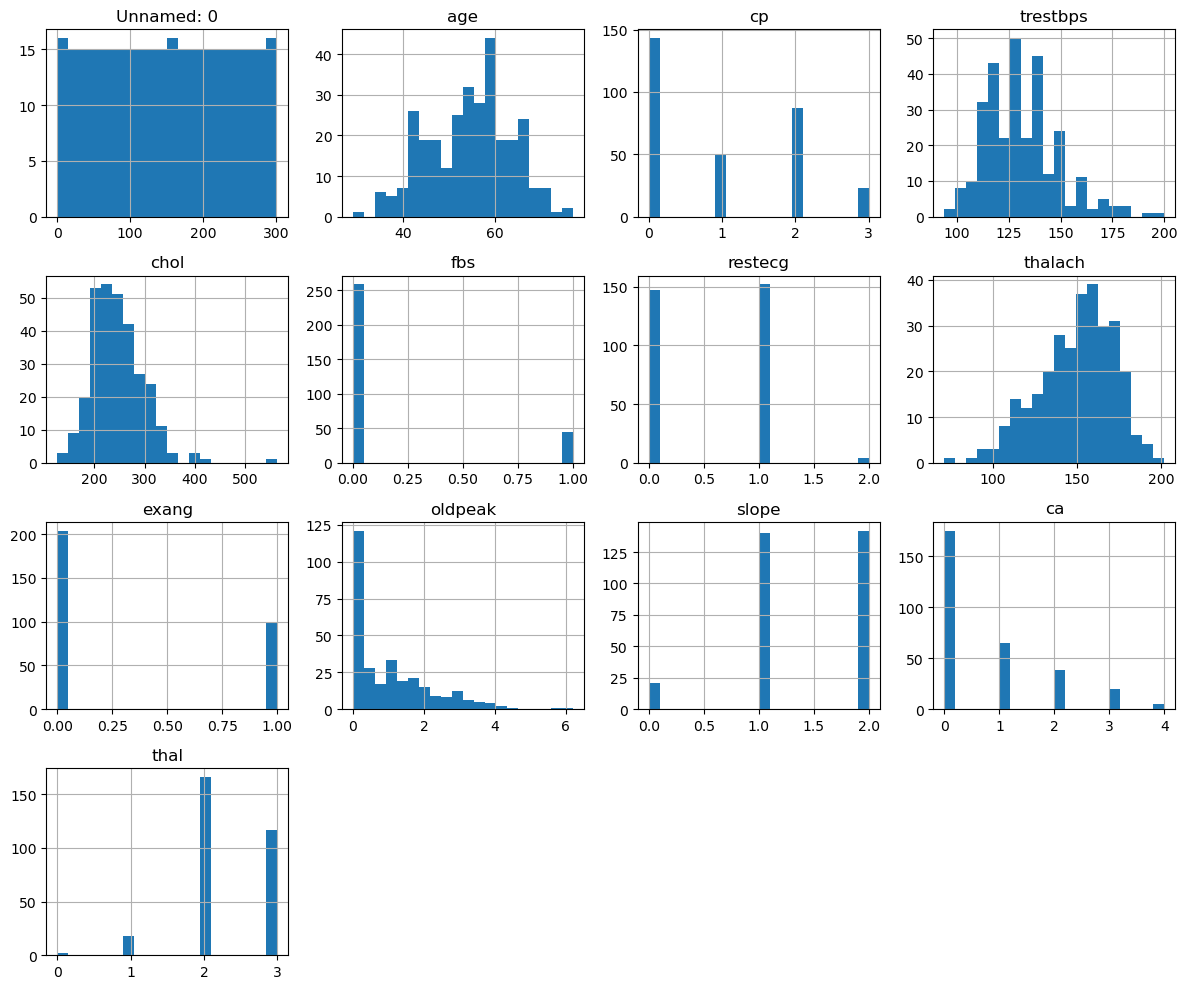


Chosen target column: target

# numeric=13, # categorical=1
Splits: 
  Train: (181, 14) 
  Valid: (61, 14) 
  Test : (61, 14)
Fitting 5 folds for each of 120 candidates, totalling 600 fits


C:\Users\Beras\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
300 fits failed out of a total of 600.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
100 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Beras\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Beras\anaconda3\Lib\site-packages\sklearn\base.py", line 1474, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Beras\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 471, in fit
    Xt = self._fit(X, y, r


Best PCA + Logistic Regression params:
{'model__C': 1.0, 'model__l1_ratio': 0.3, 'pca__n_components': 15}
Best CV F1 (PCA): 0.9794674303018335
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best params: {'model__C': 0.1, 'model__l1_ratio': 0.7}
CV best F1: 0.9948717948717949

VALID metrics -> acc=0.934  prec=1.000  rec=0.879  f1=0.935  auc=0.989
              precision    recall  f1-score   support

           0      0.875     1.000     0.933        28
           1      1.000     0.879     0.935        33

    accuracy                          0.934        61
   macro avg      0.938     0.939     0.934        61
weighted avg      0.943     0.934     0.934        61



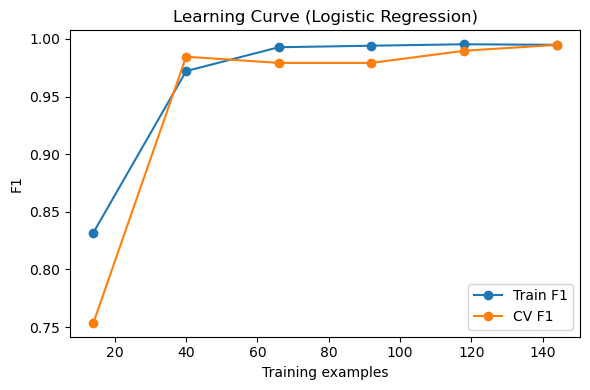


TEST metrics -> acc=0.984  prec=1.000  rec=0.970  f1=0.985  auc=0.999
              precision    recall  f1-score   support

           0      0.966     1.000     0.982        28
           1      1.000     0.970     0.985        33

    accuracy                          0.984        61
   macro avg      0.983     0.985     0.984        61
weighted avg      0.984     0.984     0.984        61



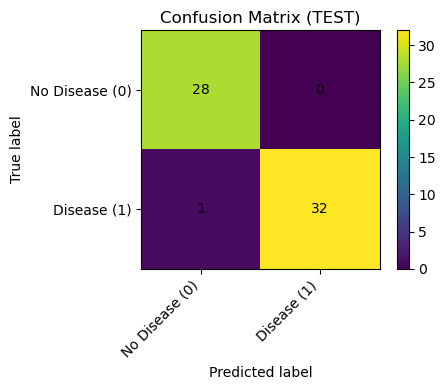

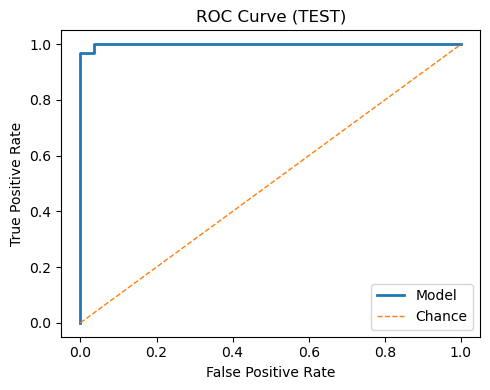


Top 20 permutation importances (VALID):


,feature,importance_mean,importance_std
0,feat_0,0.352284,0.055199
10,feat_10,0.028799,0.017158
9,feat_9,0.022902,0.015069
1,feat_1,0.000000,0.000000
2,feat_2,0.000000,0.000000
4,feat_4,0.000000,0.000000
5,feat_5,0.000000,0.000000
6,feat_6,0.000000,0.000000
7,feat_7,0.000000,0.000000
11,feat_11,0.000000,0.000000


In [28]:
# One-chunk notebook cell: EDA → fix overfitting with CV-regularized Logistic Regression

# =========================
# 0) Imports
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report
)

# =========================
# 1) Load data & quick EDA
# =========================
csv_path = "C:/Users/Beras/OneDrive/Documents/Capstone Project/heart disease classification dataset.csv"  # change path if needed
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("\nInfo:")
print(df.info())
print("\nDescribe (all cols):")
display(df.describe(include="all").T)

missing_counts = df.isna().sum().sort_values(ascending=False)
print("\nMissing values per column:")
display(missing_counts.to_frame("missing_count"))

plt.figure(figsize=(10,4))
missing_counts.plot(kind="bar")
plt.title("Missing Values per Column")
plt.xlabel("Column")
plt.ylabel("Count of Missing")
plt.tight_layout()
plt.show()

_ = df.select_dtypes(include=[np.number]).hist(bins=20, figsize=(12,10))
plt.tight_layout()
plt.show()

# =========================
# 2) Replace NAs with 0 (per instructions)
# =========================
df_filled = df.fillna(0)

# =========================
# 3) Choose target column (auto-detect; override if you know it)
# =========================
def find_target_column(frame: pd.DataFrame) -> str:
    candidates_by_name = []
    patterns = ["target","output","heartdisease","disease","hasdisease","num","label","diagnosis","class"]
    for col in frame.columns:
        name = col.lower().replace(" ", "")
        if any(p in name for p in patterns):
            candidates_by_name.append(col)
    for col in candidates_by_name:
        if frame[col].nunique(dropna=False) == 2:
            return col
    for col in candidates_by_name:
        if frame[col].nunique(dropna=False) <= 10:
            return col
    for col in frame.columns:
        if frame[col].nunique(dropna=False) == 2:
            return col
    return frame.columns[-1]

target_col = find_target_column(df_filled)
print("\nChosen target column:", target_col)

# =========================
# 4) Build X, y and guard against leakage
# =========================
y_raw = df_filled[target_col]
X_raw = df_filled.drop(columns=[target_col])

# Force binary y
if y_raw.dtype == "O":
    y = y_raw.astype(str).str.lower().map({
        '1':1,'yes':1,'true':1,'present':1,'disease':1,'positive':1,'pos':1,'y':1,'t':1
    }).fillna(0).astype(int)
else:
    y = (y_raw != 0).astype(int) if set(pd.unique(y_raw)) - {0,1} else y_raw.astype(int)

# Column types
cat_cols = [c for c in X_raw.columns if X_raw[c].dtype == "O"]
num_cols = [c for c in X_raw.columns if c not in cat_cols]
print(f"\n# numeric={len(num_cols)}, # categorical={len(cat_cols)}")

# Quick leakage checks
eq_leak = [c for c in X_raw.columns if (X_raw[c] == y).all()]
corrs = {}
for c in num_cols:
    if X_raw[c].nunique() > 1:
        corrs[c] = abs(pd.Series(X_raw[c]).corr(y))
leaky_high_corr = [c for c, r in corrs.items() if r >= 0.995]

to_drop = set(eq_leak) | set(leaky_high_corr)
if to_drop:
    print("Dropping potential leakage columns:", to_drop)
    X_raw = X_raw.drop(columns=list(to_drop))
    cat_cols = [c for c in X_raw.columns if X_raw[c].dtype == "O"]
    num_cols = [c for c in X_raw.columns if c not in cat_cols]

# =========================
# 5) Split Train / Valid / Test (60/20/20)
# =========================
X_temp, X_test, y_temp, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)  # 0.25 * 0.8 = 0.20

print("Splits:",
      "\n  Train:", X_train.shape,
      "\n  Valid:", X_valid.shape,
      "\n  Test :", X_test.shape)

# =========================
# 6) Preprocess (shrink rare cats + scale numerics)
# =========================
numeric_transformer = Pipeline(steps=[
    ("varthresh", VarianceThreshold(threshold=0.0)),
    ("scaler", StandardScaler(with_mean=False))
])

# combine categories that appear in <1% of rows to reduce one-hot explosion
categorical_transformer = OneHotEncoder(handle_unknown="ignore", min_frequency=0.01)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ],
    remainder="drop"
)

from sklearn.decomposition import PCA

# =========================
# 7) Add PCA + Elastic Net Logistic Regression
# =========================

pca = PCA(random_state=42)

logreg_pca_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("pca", pca),
    ("model", LogisticRegression(
        max_iter=2000,
        solver="saga",
        penalty="elasticnet",
        class_weight="balanced"
    ))
])

# Tune # of components + model hyperparameters
param_grid_pca = {
    "pca__n_components": [5, 10, 15, 20, 30, 50],  # depends on how wide your dataset is
    "model__C": [0.01, 0.03, 0.1, 0.3, 1.0],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7],
}

grid_pca = GridSearchCV(
    logreg_pca_clf,
    param_grid=param_grid_pca,
    scoring="f1",
    n_jobs=-1,
    cv=cv,
    refit=True,
    verbose=1
)

grid_pca.fit(X_train, y_train)
best_pca_clf = grid_pca.best_estimator_

print("\nBest PCA + Logistic Regression params:")
print(grid_pca.best_params_)
print("Best CV F1 (PCA):", grid_pca.best_score_)

# =========================
# 8) Elastic Net Logistic Regression + CV (reduce overfitting)
# =========================
base_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        solver="saga",           # supports l1/l2/elasticnet
        penalty="elasticnet",
        l1_ratio=0.5,            # tuned via grid
        class_weight="balanced"  # helpful for imbalance
    ))
])

param_grid = {
    "model__C": [0.01, 0.03, 0.1, 0.3, 1.0],   # stronger reg -> smaller C
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=base_clf,
    param_grid=param_grid,
    scoring="f1",
    n_jobs=-1,
    cv=cv,
    refit=True,
    verbose=1
)

grid.fit(X_train, y_train)
best_clf = grid.best_estimator_
print("\nBest params:", grid.best_params_)
print("CV best F1:", grid.best_score_)

# =========================
# 9) Helper: evaluation printer
# =========================
def evaluate_split(name, yt, yp, yp_prob):
    acc  = accuracy_score(yt, yp)
    prec = precision_score(yt, yp, zero_division=0)
    rec  = recall_score(yt, yp, zero_division=0)
    f1   = f1_score(yt, yp, zero_division=0)
    try:
        auc = roc_auc_score(yt, yp_prob)
    except Exception:
        auc = np.nan
    print(f"\n{name} metrics -> acc={acc:.3f}  prec={prec:.3f}  rec={rec:.3f}  f1={f1:.3f}  auc={auc:.3f}")
    print(classification_report(yt, yp, digits=3, zero_division=0))
    return acc, prec, rec, f1, auc

# =========================
# 10) VALID evaluation
# =========================
y_valid_pred = best_clf.predict(X_valid)
y_valid_prob = best_clf.predict_proba(X_valid)[:, 1]
evaluate_split("VALID", y_valid, y_valid_pred, y_valid_prob)

# Learning curve (diagnose overfitting)
train_sizes, train_scores, valid_scores = learning_curve(
    best_clf, X_train, y_train,
    cv=cv, scoring="f1", n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 6),
    shuffle=True, random_state=42
)
plt.figure(figsize=(6,4))
plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train F1")
plt.plot(train_sizes, valid_scores.mean(axis=1), marker="o", label="CV F1")
plt.xlabel("Training examples")
plt.ylabel("F1")
plt.title("Learning Curve (Logistic Regression)")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 11) FINAL TEST evaluation (only once)
# =========================
y_test_pred = best_clf.predict(X_test)
y_test_prob = best_clf.predict_proba(X_test)[:, 1]
evaluate_split("TEST", y_test, y_test_pred, y_test_prob)

# Confusion Matrix (TEST)
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix (TEST)")
plt.colorbar()
classes = ["No Disease (0)", "Disease (1)"]
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45, ha="right")
plt.yticks(tick_marks, classes)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i,j]), ha="center", va="center")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

# ROC curve (TEST)
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, linewidth=2, label="Model")
plt.plot([0,1],[0,1], linestyle="--", linewidth=1, label="Chance")
plt.title("ROC Curve (TEST)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 12) (Optional) Permutation importance on VALID set
#      (helps spot leakage or overly powerful features)
# =========================
from sklearn.inspection import permutation_importance

r = permutation_importance(
    best_clf, X_valid, y_valid, n_repeats=10, scoring="f1", n_jobs=-1, random_state=42
)
# Safest: map to generic names equal to transformed feature count
n_feats = best_clf.named_steps["preprocess"].transform(X_valid).shape[1]
feat_names = np.array([f"feat_{i}" for i in range(n_feats)])

importances = pd.DataFrame({
    "feature": feat_names[:len(r.importances_mean)],
    "importance_mean": r.importances_mean,
    "importance_std": r.importances_std
}).sort_values("importance_mean", ascending=False)

print("\nTop 20 permutation importances (VALID):")
display(importances.head(20))


Fitting 5 folds for each of 28 candidates, totalling 140 fits
Best KNN params: {'model__n_neighbors': 11, 'model__p': 2, 'model__weights': 'uniform'}
CV best F1 (KNN): 0.9459072506440928

VALID (KNN) metrics:
  Accuracy : 0.885
  Precision: 0.906
  Recall   : 0.879
  F1-score : 0.892

Classification report:
              precision    recall  f1-score   support

           0      0.862     0.893     0.877        28
           1      0.906     0.879     0.892        33

    accuracy                          0.885        61
   macro avg      0.884     0.886     0.885        61
weighted avg      0.886     0.885     0.885        61



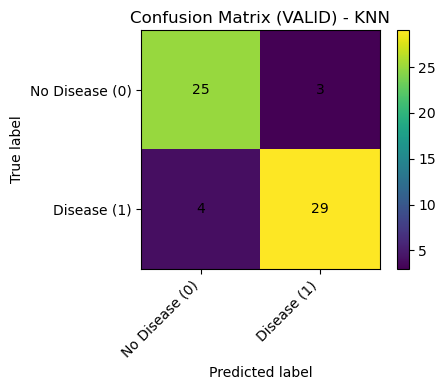


TEST (KNN) metrics:
  Accuracy : 0.885
  Precision: 0.842
  Recall   : 0.970
  F1-score : 0.901

Classification report:
              precision    recall  f1-score   support

           0      0.957     0.786     0.863        28
           1      0.842     0.970     0.901        33

    accuracy                          0.885        61
   macro avg      0.899     0.878     0.882        61
weighted avg      0.895     0.885     0.884        61



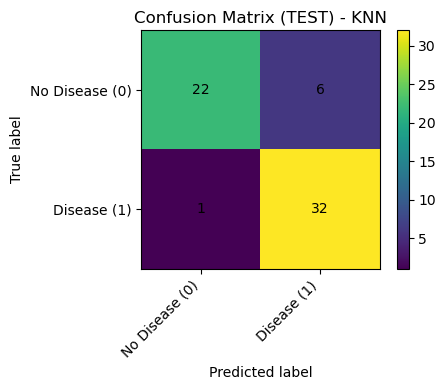

In [30]:
# ---- KNN with metrics (Accuracy, Precision, Recall, F1) + Confusion Matrices (VALID & TEST) ----
# Drop this AFTER your earlier cells so X_train/X_valid/X_test etc. exist.
# If you restarted the kernel, this cell will rebuild from the CSV.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

# ---------- Rebuild data if needed ----------
rebuild_needed = False
for name in ["X_train","X_valid","X_test","y_train","y_valid","y_test","num_cols","cat_cols"]:
    if name not in globals():
        rebuild_needed = True
        break

if rebuild_needed:
    # Adjust path if needed:
    csv_path = "C:/Users/Beras/OneDrive/Documents/Capstone Project/heart disease classification dataset.csv"
    df = pd.read_csv(csv_path)
    df_filled = df.fillna(0)

    # Target finder (same heuristic used before)
    def find_target_column(frame: pd.DataFrame) -> str:
        candidates_by_name, patterns = [], ["target","output","heartdisease","disease","hasdisease","num","label","diagnosis","class"]
        for col in frame.columns:
            name = col.lower().replace(" ", "")
            if any(p in name for p in patterns):
                candidates_by_name.append(col)
        for col in candidates_by_name:
            if frame[col].nunique(dropna=False) == 2:
                return col
        for col in candidates_by_name:
            if frame[col].nunique(dropna=False) <= 10:
                return col
        for col in frame.columns:
            if frame[col].nunique(dropna=False) == 2:
                return col
        return frame.columns[-1]

    target_col = find_target_column(df_filled)
    y_raw = df_filled[target_col]
    X_raw = df_filled.drop(columns=[target_col])

    # Make y binary
    if y_raw.dtype == "O":
        y = y_raw.astype(str).str.lower().map({
            '1':1,'yes':1,'true':1,'present':1,'disease':1,'positive':1,'pos':1,'y':1,'t':1
        }).fillna(0).astype(int)
    else:
        y = (y_raw != 0).astype(int) if set(pd.unique(y_raw)) - {0,1} else y_raw.astype(int)

    cat_cols = [c for c in X_raw.columns if X_raw[c].dtype == "O"]
    num_cols = [c for c in X_raw.columns if c not in cat_cols]

    # Simple leakage guard
    eq_leak = [c for c in X_raw.columns if (X_raw[c] == y).all()]
    corrs = {}
    for c in num_cols:
        if X_raw[c].nunique() > 1:
            corrs[c] = abs(pd.Series(X_raw[c]).corr(y))
    leaky_high_corr = [c for c, r in corrs.items() if r >= 0.995]
    to_drop = set(eq_leak) | set(leaky_high_corr)
    if to_drop:
        X_raw = X_raw.drop(columns=list(to_drop))
        cat_cols = [c for c in X_raw.columns if X_raw[c].dtype == "O"]
        num_cols = [c for c in X_raw.columns if c not in cat_cols]

    X_temp, X_test, y_temp, y_test = train_test_split(
        X_raw, y, test_size=0.20, random_state=42, stratify=y
    )
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
    )

# ---------- Preprocessing tailored for KNN ----------
numeric_transformer_knn = Pipeline(steps=[
    ("varthresh", VarianceThreshold(threshold=0.0)),
    ("scaler", StandardScaler(with_mean=False))  # keep sparse compatibility
])

categorical_transformer_knn = OneHotEncoder(
    handle_unknown="ignore",
    min_frequency=0.01  # collapse rare categories
)

preprocessor_knn = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_knn, num_cols),
        ("cat", categorical_transformer_knn, cat_cols)
    ],
    remainder="drop"
)

# ---------- KNN + CV ----------
knn_pipe = Pipeline(steps=[
    ("preprocess", preprocessor_knn),
    ("model", KNeighborsClassifier())
])

param_grid_knn = {
    "model__n_neighbors": [3,5,7,9,11,15,21],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],  # Manhattan vs Euclidean
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_knn = GridSearchCV(
    estimator=knn_pipe,
    param_grid=param_grid_knn,
    scoring="f1",
    n_jobs=-1,
    cv=cv,
    refit=True,
    verbose=1
)

grid_knn.fit(X_train, y_train)
best_knn = grid_knn.best_estimator_
print("Best KNN params:", grid_knn.best_params_)
print("CV best F1 (KNN):", grid_knn.best_score_)

# ---------- Helpers ----------
def compute_metrics(y_true, y_pred, y_prob=None):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = (roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan)
    return acc, prec, rec, f1, auc

def print_and_confmat(name, y_true, y_pred):
    acc, prec, rec, f1, _ = compute_metrics(y_true, y_pred, None)
    print(f"\n{name} (KNN) metrics:")
    print(f"  Accuracy : {acc:.3f}")
    print(f"  Precision: {prec:.3f}")
    print(f"  Recall   : {rec:.3f}")
    print(f"  F1-score : {f1:.3f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=3, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion Matrix ({name}) - KNN")
    plt.colorbar()
    classes = ["No Disease (0)", "Disease (1)"]
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha="right")
    plt.yticks(tick_marks, classes)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i,j]), ha="center", va="center")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

# ---------- VALID metrics + Confusion Matrix ----------
y_valid_pred_knn = best_knn.predict(X_valid)
print_and_confmat("VALID", y_valid, y_valid_pred_knn)

# ---------- TEST metrics + Confusion Matrix ----------
y_test_pred_knn = best_knn.predict(X_test)
print_and_confmat("TEST", y_test, y_test_pred_knn)


In [32]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report
)
import numpy as np

def evaluate_split(name, yt, yp, yp_prob):
    acc  = accuracy_score(yt, yp)
    prec = precision_score(yt, yp, zero_division=0)
    rec  = recall_score(yt, yp, zero_division=0)
    f1   = f1_score(yt, yp, zero_division=0)
    try:
        auc = roc_auc_score(yt, yp_prob)
    except Exception:
        auc = np.nan
    print(f"\n{name} metrics -> acc={acc:.3f}  prec={prec:.3f}  rec={rec:.3f}  f1={f1:.3f}  auc={auc:.3f}")
    print(classification_report(yt, yp, digits=3, zero_division=0))
    return acc, prec, rec, f1, auc


In [34]:
from sklearn.decomposition import PCA

# =========================
# 7) Add PCA + Elastic Net Logistic Regression
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pca = PCA(random_state=42)

logreg_pca_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("pca", pca),
    ("model", LogisticRegression(
        max_iter=2000,
        solver="saga",
        penalty="elasticnet",
        class_weight="balanced"
    ))
])

# Tune # of components + model hyperparameters
param_grid_pca = {
    "pca__n_components": [5, 10, 15, 20, 30, 50],  # depends on how wide your dataset is
    "model__C": [0.01, 0.03, 0.1, 0.3, 1.0],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7],
}

grid_pca = GridSearchCV(
    logreg_pca_clf,
    param_grid=param_grid_pca,
    scoring="f1",
    n_jobs=-1,
    cv=cv,
    refit=True,
    verbose=1
)

grid_pca.fit(X_train, y_train)
best_pca_clf = grid_pca.best_estimator_

print("\nBest PCA + Logistic Regression params:")
print(grid_pca.best_params_)
print("Best CV F1 (PCA):", grid_pca.best_score_)


Fitting 5 folds for each of 120 candidates, totalling 600 fits

Best PCA + Logistic Regression params:
{'model__C': 1.0, 'model__l1_ratio': 0.5, 'pca__n_components': 15}
Best CV F1 (PCA): 0.9794674303018335


C:\Users\Beras\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
300 fits failed out of a total of 600.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
100 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Beras\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Beras\anaconda3\Lib\site-packages\sklearn\base.py", line 1474, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Beras\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 471, in fit
    Xt = self._fit(X, y, r

In [35]:
# VALID metrics
y_valid_pred_pca = best_pca_clf.predict(X_valid)
y_valid_prob_pca = best_pca_clf.predict_proba(X_valid)[:, 1]
evaluate_split("VALID (PCA Logistic)", y_valid, y_valid_pred_pca, y_valid_prob_pca)

# TEST metrics
y_test_pred_pca = best_pca_clf.predict(X_test)
y_test_prob_pca = best_pca_clf.predict_proba(X_test)[:, 1]
evaluate_split("TEST (PCA Logistic)", y_test, y_test_pred_pca, y_test_prob_pca)



VALID (PCA Logistic) metrics -> acc=1.000  prec=1.000  rec=1.000  f1=1.000  auc=1.000
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        28
           1      1.000     1.000     1.000        33

    accuracy                          1.000        61
   macro avg      1.000     1.000     1.000        61
weighted avg      1.000     1.000     1.000        61


TEST (PCA Logistic) metrics -> acc=0.984  prec=0.971  rec=1.000  f1=0.985  auc=1.000
              precision    recall  f1-score   support

           0      1.000     0.964     0.982        28
           1      0.971     1.000     0.985        33

    accuracy                          0.984        61
   macro avg      0.985     0.982     0.983        61
weighted avg      0.984     0.984     0.984        61



(0.9836065573770492, 0.9705882352941176, 1.0, 0.9850746268656716, 1.0)

In [38]:
# ---------- Preprocessing tailored for KNN ----------
numeric_transformer_knn = Pipeline(steps=[
    ("varthresh", VarianceThreshold(threshold=0.0)),
    ("scaler", StandardScaler(with_mean=False))
])

categorical_transformer_knn = OneHotEncoder(
    handle_unknown="ignore",
    min_frequency=0.01
)

preprocessor_knn = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_knn, num_cols),
        ("cat", categorical_transformer_knn, cat_cols)
    ],
    remainder="drop"
)


In [40]:
# =========================
# PCA + KNN
# =========================
pca_knn_pipe = Pipeline(steps=[
    ("preprocess", preprocessor_knn),
    ("pca", PCA(random_state=42)),
    ("model", KNeighborsClassifier())
])

param_grid_knn_pca = {
    "pca__n_components": [5, 10, 15, 20, 30, 50],
    "model__n_neighbors": [3,5,7,9,11,15],
    "model__weights": ["uniform", "distance"],
    "model__p": [1,2],
}

grid_knn_pca = GridSearchCV(
    estimator=pca_knn_pipe,
    param_grid=param_grid_knn_pca,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_knn_pca.fit(X_train, y_train)
best_knn_pca = grid_knn_pca.best_estimator_

print("\nBest PCA + KNN Params:", grid_knn_pca.best_params_)
print("Best CV F1 (PCA+KNN):", grid_knn_pca.best_score_)


Fitting 5 folds for each of 144 candidates, totalling 720 fits

Best PCA + KNN Params: {'model__n_neighbors': 9, 'model__p': 1, 'model__weights': 'uniform', 'pca__n_components': 15}
Best CV F1 (PCA+KNN): 0.9471661671661671


C:\Users\Beras\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
360 fits failed out of a total of 720.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
120 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Beras\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Beras\anaconda3\Lib\site-packages\sklearn\base.py", line 1474, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Beras\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 471, in fit
    Xt = self._fit(X, y, r

In [42]:
# VALID metrics
y_valid_pred_knn_pca = best_knn_pca.predict(X_valid)
y_valid_prob_knn_pca = best_knn_pca.predict_proba(X_valid)[:, 1]

evaluate_split(
    "VALID (PCA + KNN)",
    y_valid,
    y_valid_pred_knn_pca,
    y_valid_prob_knn_pca
)

# TEST metrics
y_test_pred_knn_pca = best_knn_pca.predict(X_test)
y_test_prob_knn_pca = best_knn_pca.predict_proba(X_test)[:, 1]

evaluate_split(
    "TEST (PCA + KNN)",
    y_test,
    y_test_pred_knn_pca,
    y_test_prob_knn_pca
)



VALID (PCA + KNN) metrics -> acc=0.934  prec=0.914  rec=0.970  f1=0.941  auc=0.965
              precision    recall  f1-score   support

           0      0.962     0.893     0.926        28
           1      0.914     0.970     0.941        33

    accuracy                          0.934        61
   macro avg      0.938     0.931     0.934        61
weighted avg      0.936     0.934     0.934        61


TEST (PCA + KNN) metrics -> acc=0.902  prec=0.865  rec=0.970  f1=0.914  auc=0.965
              precision    recall  f1-score   support

           0      0.958     0.821     0.885        28
           1      0.865     0.970     0.914        33

    accuracy                          0.902        61
   macro avg      0.912     0.896     0.899        61
weighted avg      0.908     0.902     0.901        61



(0.9016393442622951,
 0.8648648648648649,
 0.9696969696969697,
 0.9142857142857143,
 0.9648268398268399)

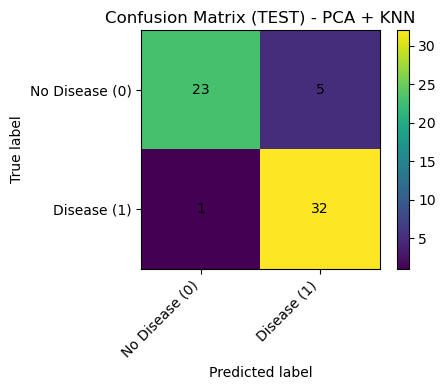

In [44]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_test_pred_knn_pca)

plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix (TEST) - PCA + KNN")
plt.colorbar()
classes = ["No Disease (0)", "Disease (1)"]
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45, ha="right")
plt.yticks(tick_marks, classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i,j]), ha="center", va="center")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()
